# IF25-40305: Sistem Teknologi Multimedia (STM)
## Modul 03 — Visualisasi Rekaman Kelas: Waveform, Spektrum FFT & Mel-Spektrogram

**Institut Teknologi Sumatera (ITERA) — Program Studi Informatika**
*Materi Kuliah & Hands-on Lab Semester Ganjil 2026/2027*

---

Modul 02 membedah sebuah berkas musik studio yang bersih. Pada modul ini kita menerapkan tiga
representasi visual yang sama pada **rekaman nyata yang diambil langsung di dalam kelas**
(`audio/audio_dikelas.wav`), lengkap dengan segala ketidaksempurnaannya: gema ruangan, derau
latar, dan jarak mikrofon yang tidak ideal.

| Representasi | Sumbu | Pertanyaan yang dijawab |
|---|---|---|
| **Waveform** | Amplitudo vs waktu | *Kapan* suara keras, kapan hening? |
| **Spektrum FFT (logaritmik)** | Magnitudo (dBFS) vs frekuensi (skala log) | *Frekuensi apa saja* yang ada, dan seberapa kuat? |
| **Mel-spektrogram** | Frekuensi Mel vs waktu, warna = energi | *Frekuensi apa, kapan* — sesuai cara telinga mendengar |


## 1. Import Library & Persiapan Lingkungan

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window
import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

# Palet warna yang sama dengan Modul 02
C_SIGNAL   = '#0284c7'   # biru   — sinyal utama
C_NEUTRAL  = '#334155'   # slate  — teks netral
C_ALERT    = '#dc2626'   # merah  — batas bahaya, sorotan
C_GOOD     = '#059669'   # hijau  — spektrum
C_GOLD     = '#c5a059'   # emas   — panel Mel

print(f"numpy      : {np.__version__}")
print(f"librosa    : {librosa.__version__}")
print(f"soundfile  : {sf.__version__}")

numpy      : 2.5.3
librosa    : 1.0.0
soundfile  : 0.14.0


## 2. Memuat Rekaman Kelas

Rekaman asli berformat **M4A (AAC)** dari perekam ponsel, lalu dikonversi ke **WAV 16-bit PCM**
dengan `ffmpeg` agar dapat dibaca langsung oleh `soundfile`/`librosa`:

```bash
ffmpeg -i audio_dikelas.m4a -af "volume=-8.8dB" -ac 1 -ar 48000 -c:a pcm_s16le audio_dikelas.wav
```

> ℹ️ **Mengapa ada `volume=-8.8dB`?** Decoder AAC menghasilkan sampel *floating-point* yang
> puncaknya mencapai $\approx 2{,}45$ — jauh di atas batas $\pm 1{,}0$. Bila langsung dikonversi ke
> integer 16-bit, lebih dari 5.500 sampel akan terpotong rata (*clipping* buatan). Penguatan
> $-8{,}8\text{ dB}$ menurunkan puncaknya tepat ke $-1\text{ dBFS}$ sehingga bentuk gelombang asli
> tetap utuh.

Kita memuat berkas pada **laju sampel aslinya** (`sr=None`), yaitu $48\text{ kHz}$, agar seluruh
rentang frekuensi hingga Nyquist $24\text{ kHz}$ tetap dapat diamati.


In [2]:
# Pencarian berkas defensif: berjalan dari root repositori maupun dari folder notebook_handson/
possible_paths = [
    'audio/audio_dikelas.wav',
    'notebook_handson/audio/audio_dikelas.wav',
]
audio_path = next((p for p in possible_paths if os.path.exists(p)), None)
assert audio_path is not None, "Berkas audio_dikelas.wav tidak ditemukan."

y, sr = librosa.load(audio_path, sr=None, mono=True)
t = np.arange(len(y)) / sr

peak = np.max(np.abs(y))
rms = np.sqrt(np.mean(y ** 2))

print(f"Sumber berkas     : {audio_path}")
print(f"Laju sampel       : {sr} Hz  (Nyquist {sr // 2} Hz)")
print(f"Jumlah sampel     : {len(y)} sampel")
print(f"Durasi            : {len(y) / sr:.2f} detik")
print(f"Puncak amplitudo  : {peak:.3f} ({20 * np.log10(peak):.2f} dBFS)")
print(f"RMS               : {rms:.3f} ({20 * np.log10(rms):.2f} dBFS)")
print(f"Crest factor      : {20 * np.log10(peak / rms):.1f} dB")

ipd.Audio(y, rate=sr)

Sumber berkas     : audio/audio_dikelas.wav
Laju sampel       : 48000 Hz  (Nyquist 24000 Hz)
Jumlah sampel     : 312256 sampel
Durasi            : 6.51 detik
Puncak amplitudo  : 0.891 (-1.00 dBFS)
RMS               : 0.124 (-18.12 dBFS)
Crest factor      : 17.1 dB


## 3. Domain Waktu: Waveform

Sumbu X adalah waktu, sumbu Y adalah amplitudo ($-1{,}0$ hingga $+1{,}0$). Garis putus-putus merah
menandai batas $0\text{ dBFS}$; sinyal yang menyentuhnya berarti *clipping*.

Di atas waveform kita tumpangkan **selubung RMS** (*RMS envelope*), yaitu rata-rata energi per
jendela pendek. Selubung ini membantu mata membedakan bagian yang sungguh keras dari paku
sesaat, dan memperlihatkan jeda antar-ucapan dengan lebih jelas.


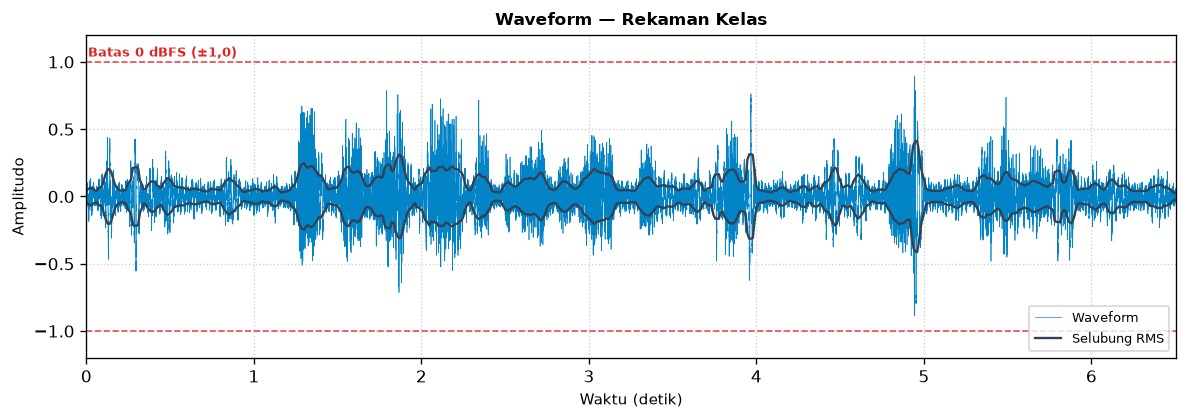

RMS per jendela   : -32.0 dBFS (tersepi) s.d. -7.7 dBFS (terkeras)
Rentang dinamis   : 24.3 dB


Sampel clipping   : 0


In [3]:
FRAME = 2048
HOP = 512

rms_env = librosa.feature.rms(y=y, frame_length=FRAME, hop_length=HOP)[0]
t_env = librosa.frames_to_time(np.arange(len(rms_env)), sr=sr, hop_length=HOP)

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(t, y, color=C_SIGNAL, lw=0.4, label='Waveform')
ax.plot(t_env, rms_env, color=C_NEUTRAL, lw=1.4, label='Selubung RMS')
ax.plot(t_env, -rms_env, color=C_NEUTRAL, lw=1.4)
for batas in (1.0, -1.0):
    ax.axhline(batas, color=C_ALERT, lw=1.0, linestyle='--', alpha=0.8)
ax.text(0.01, 1.04, "Batas 0 dBFS (±1,0)", color=C_ALERT, fontsize=8, fontweight='bold')

ax.set_title("Waveform — Rekaman Kelas", fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Amplitudo", fontsize=9)
ax.set_xlim(0, t[-1])
ax.set_ylim(-1.2, 1.2)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

rms_db = 20 * np.log10(np.maximum(rms_env, 1e-10))
print(f"RMS per jendela   : {rms_db.min():.1f} dBFS (tersepi) s.d. {rms_db.max():.1f} dBFS (terkeras)")
print(f"Rentang dinamis   : {rms_db.max() - rms_db.min():.1f} dB")
print(f"Sampel clipping   : {int(np.sum(np.abs(y) >= 0.999))}")

## 4. Domain Frekuensi: Spektrum FFT Logaritmik

Spektrum FFT merangkum **seluruh durasi rekaman** menjadi satu kurva magnitudo per frekuensi.
Dua skala logaritmik dipakai sekaligus:

- **Sumbu X logaritmik** (`semilogx`): setiap oktaf (penggandaan frekuensi) mendapat lebar yang
  sama. Ini sesuai dengan telinga, yang mendengar $100 \to 200\text{ Hz}$ sebagai lompatan nada
  yang sama besarnya dengan $1000 \to 2000\text{ Hz}$.
- **Sumbu Y dalam dBFS**: $20\log_{10}(|X|)$, sehingga komponen yang $1000\times$ lebih lemah
  tetap terlihat ($-60\text{ dB}$) alih-alih tenggelam di dasar grafik.

Perhitungannya memakai fungsi `spectrum_dbfs` dari Modul 02: *window* Hann dengan koreksi
normalisasi, lalu dirata-ratakan lintas jendela yang bertumpang tindih 50% (metode Welch)
agar kurva tidak bergerigi. Sinus berpuncak $1{,}0$ akan terbaca tepat $0\text{ dBFS}$.


In [4]:
def spectrum_dbfs(x, sr, n_fft=4096, average=True):
    """Menghitung spektrum satu sisi berskala dBFS yang terkalibrasi.

    Bila `average=True` dan sinyal lebih panjang dari satu jendela, magnitudo
    dirata-ratakan lintas jendela yang saling bertumpang tindih 50%.

    Mengembalikan (frekuensi_hz, magnitudo_dbfs).
    """
    x = np.asarray(x, dtype=float)
    if len(x) < n_fft:
        x = np.pad(x, (0, n_fft - len(x)))

    w = get_window('hann', n_fft, fftbins=True)
    hop = n_fft // 2
    n_frames = 1 + (len(x) - n_fft) // hop if average else 1

    akumulasi = np.zeros(n_fft // 2 + 1)
    for i in range(n_frames):
        seg = x[i * hop: i * hop + n_fft]
        akumulasi += np.abs(np.fft.rfft(seg * w))
    mag = akumulasi / n_frames / np.sum(w)

    # Koreksi spektrum satu sisi, kecuali bin DC dan bin Nyquist
    mag[1:-1] *= 2.0

    db = 20 * np.log10(np.maximum(mag, 1e-12))
    freqs = np.fft.rfftfreq(n_fft, 1 / sr)
    return freqs, db

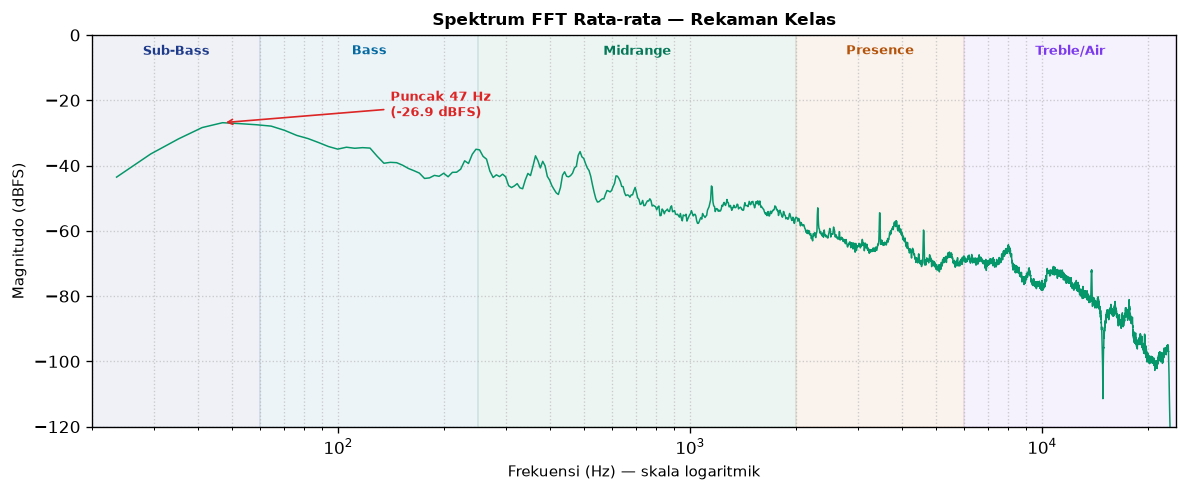

Resolusi frekuensi (Δf) : 5.86 Hz per bin
Jumlah jendela dirata-rata: 75
Puncak spektrum          : 46.9 Hz, -26.9 dBFS

Porsi energi per zona:
  Sub-Bass       20–   60 Hz :  35.3%  ██████████████████
  Bass           60–  250 Hz :  39.4%  ████████████████████
  Midrange      250– 2000 Hz :  23.6%  ████████████
  Presence     2000– 6000 Hz :   1.4%  █
  Treble/Air   6000–24000 Hz :   0.4%  


In [5]:
N_FFT_SPEC = 8192
freqs, db = spectrum_dbfs(y, sr, n_fft=N_FFT_SPEC)

# Lima zona spektrum audio (sama dengan Modul 02), batas atas diperluas ke Nyquist 24 kHz
ZONA = [
    (20,   60,     'Sub-Bass',   '#1e3a8a'),
    (60,   250,    'Bass',       '#0369a1'),
    (250,  2000,   'Midrange',   '#047857'),
    (2000, 6000,   'Presence',   '#b45309'),
    (6000, sr / 2, 'Treble/Air', '#7c3aed'),
]

band = freqs >= 20
i_peak = int(np.argmax(np.where(band, db, -np.inf)))

fig, ax = plt.subplots(figsize=(10, 4.2))
for f_lo, f_hi, label, warna in ZONA:
    ax.axvspan(f_lo, f_hi, color=warna, alpha=0.07)
    ax.text(np.sqrt(f_lo * f_hi), -3, label, ha='center', va='top',
            fontsize=7.5, fontweight='bold', color=warna)

ax.semilogx(freqs[band], db[band], color=C_GOOD, lw=0.9)
ax.annotate(f"Puncak {freqs[i_peak]:.0f} Hz\n({db[i_peak]:.1f} dBFS)",
            xy=(freqs[i_peak], db[i_peak]), xytext=(freqs[i_peak] * 3, db[i_peak] + 2),
            fontsize=7.5, fontweight='bold', color=C_ALERT,
            arrowprops=dict(arrowstyle='->', color=C_ALERT, lw=1.0))

ax.set_title("Spektrum FFT Rata-rata — Rekaman Kelas", fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi (Hz) — skala logaritmik", fontsize=9)
ax.set_ylabel("Magnitudo (dBFS)", fontsize=9)
ax.set_xlim(20, sr / 2)
ax.set_ylim(-120, 0)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Resolusi frekuensi (Δf) : {sr / N_FFT_SPEC:.2f} Hz per bin")
print(f"Jumlah jendela dirata-rata: {1 + (len(y) - N_FFT_SPEC) // (N_FFT_SPEC // 2)}")
print(f"Puncak spektrum          : {freqs[i_peak]:.1f} Hz, {db[i_peak]:.1f} dBFS\n")

# Porsi energi per zona: dihitung dari spektrum daya linier, bukan dari nilai dB
daya = 10 ** (db / 10)
total = daya[band].sum()
print("Porsi energi per zona:")
for f_lo, f_hi, label, _ in ZONA:
    m = (freqs >= f_lo) & (freqs < f_hi)
    porsi = 100 * daya[m].sum() / total
    print(f"  {label:<11} {f_lo:>5.0f}–{f_hi:>5.0f} Hz : {porsi:5.1f}%  {'█' * int(round(porsi / 2))}")

## 5. Domain Waktu-Frekuensi: Mel-Spektrogram

Spektrum FFT di atas kehilangan informasi **kapan** sebuah frekuensi muncul. Mel-spektrogram
mengembalikannya: STFT dihitung per jendela pendek, lalu sumbu frekuensinya dipetakan ke
**skala Mel** — rapat di frekuensi rendah dan renggang di frekuensi tinggi, meniru resolusi
telinga manusia.

| Parameter | Nilai | Makna |
|---|---|---|
| `n_fft` | 2048 | Jendela $\approx 42{,}7\text{ ms}$ pada $48\text{ kHz}$ |
| `hop_length` | 512 | Pergeseran $\approx 10{,}7\text{ ms}$ antar-bingkai |
| `n_mels` | 128 | Jumlah pita Mel |
| `fmax` | $24\text{ kHz}$ | Hingga Nyquist |

> ⚠️ `melspectrogram` mengembalikan **daya** (*power*), sehingga konversinya ke desibel memakai
> `power_to_db`, bukan `amplitude_to_db`.


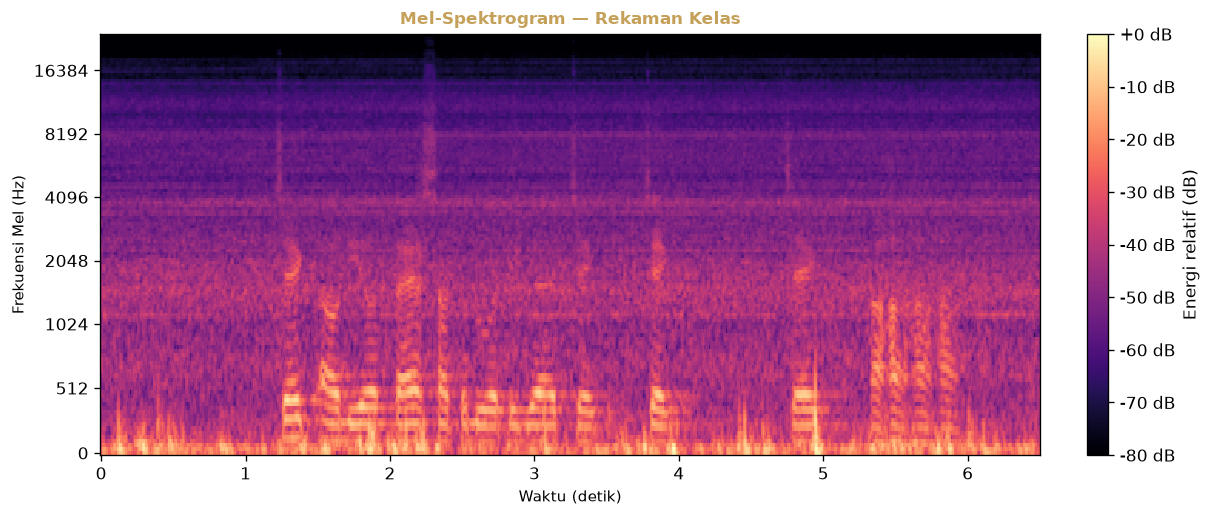

Dimensi Mel-spektrogram : 128 pita Mel × 610 bingkai waktu
Rentang warna           : -80 dB s.d. 0 dB (relatif puncak)


In [6]:
N_FFT = 2048
N_MELS = 128

S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP,
                                       n_mels=N_MELS, fmax=sr / 2)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

fig, ax = plt.subplots(figsize=(10, 4.2), constrained_layout=True)
img = librosa.display.specshow(S_mel_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                               x_axis='time', y_axis='mel', fmax=sr / 2,
                               ax=ax, cmap='magma')
ax.set_title("Mel-Spektrogram — Rekaman Kelas", fontsize=10, fontweight='bold', color=C_GOLD)
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Frekuensi Mel (Hz)", fontsize=9)
fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Energi relatif (dB)')
plt.show()

print(f"Dimensi Mel-spektrogram : {S_mel_db.shape[0]} pita Mel × {S_mel_db.shape[1]} bingkai waktu")
print(f"Rentang warna           : {S_mel_db.min():.0f} dB s.d. {S_mel_db.max():.0f} dB (relatif puncak)")

## 6. Rangkuman: Tiga Tampilan, Satu Rekaman

Ketiga representasi di bawah digambar dengan **sumbu waktu yang sejajar** (waveform dan
Mel-spektrogram), sehingga sebuah peristiwa dapat dilacak dari satu tampilan ke tampilan
lainnya. Spektrum FFT tidak memiliki sumbu waktu — ia adalah ringkasan seluruh durasi.

| Tampilan | Kekuatan | Kelemahan |
|---|---|---|
| Waveform | Presisi waktu, deteksi clipping & hening | Buta frekuensi |
| Spektrum FFT | Presisi frekuensi, kalibrasi dBFS | Buta waktu |
| Mel-spektrogram | Waktu **dan** frekuensi, selaras persepsi | Resolusi keduanya dikompromikan; amplitudo hanya relatif |


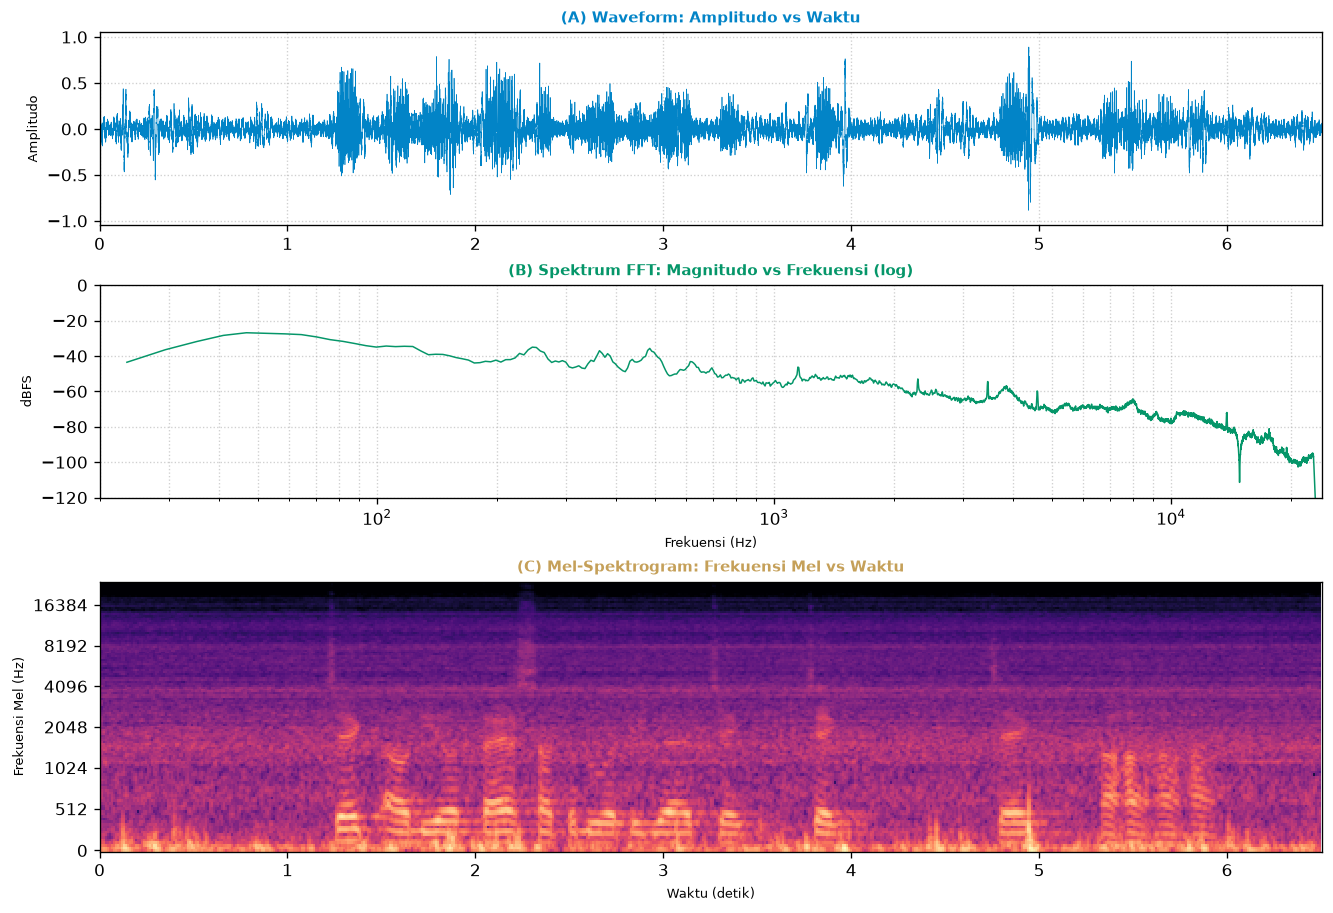

In [7]:
fig = plt.figure(figsize=(11, 7.5), constrained_layout=True)
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1.1, 1.4])

ax_w = fig.add_subplot(gs[0])
ax_w.plot(t, y, color=C_SIGNAL, lw=0.4)
ax_w.set_title("(A) Waveform: Amplitudo vs Waktu", fontsize=9, fontweight='bold', color=C_SIGNAL)
ax_w.set_ylabel("Amplitudo", fontsize=8)
ax_w.set_xlim(0, t[-1])
ax_w.set_ylim(-1.05, 1.05)
ax_w.grid(True, linestyle=':', alpha=0.6)

ax_f = fig.add_subplot(gs[1])
ax_f.semilogx(freqs[band], db[band], color=C_GOOD, lw=0.9)
ax_f.set_title("(B) Spektrum FFT: Magnitudo vs Frekuensi (log)", fontsize=9,
               fontweight='bold', color=C_GOOD)
ax_f.set_xlabel("Frekuensi (Hz)", fontsize=8)
ax_f.set_ylabel("dBFS", fontsize=8)
ax_f.set_xlim(20, sr / 2)
ax_f.set_ylim(-120, 0)
ax_f.grid(True, which='both', linestyle=':', alpha=0.6)

ax_m = fig.add_subplot(gs[2], sharex=ax_w)
librosa.display.specshow(S_mel_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                         x_axis='time', y_axis='mel', fmax=sr / 2, ax=ax_m, cmap='magma')
ax_m.set_title("(C) Mel-Spektrogram: Frekuensi Mel vs Waktu", fontsize=9,
               fontweight='bold', color=C_GOLD)
ax_m.set_xlabel("Waktu (detik)", fontsize=8)
ax_m.set_ylabel("Frekuensi Mel (Hz)", fontsize=8)

plt.show()

### 🔎 Pengamatan pada Rekaman Ini

1. **Ucapan** tampak sebagai gumpalan energi pada waveform, dan sebagai **deret harmonik
   bertingkat** di bawah $\sim 2\text{ kHz}$ pada Mel-spektrogram — pita-pita sejajar yang naik-turun
   mengikuti intonasi pembicara.
2. **Energi sub-bass sangat dominan** (lebih dari sepertiga total energi berada di bawah
   $60\text{ Hz}$). Bentuknya berupa punuk lebar, bukan duri sempit, sehingga ini **bukan** dengung
   jala listrik $50\text{ Hz}$ melainkan gemuruh (*rumble*) — kemungkinan dari AC, getaran meja,
   atau gesekan pada ponsel. Pada Mel-spektrogram ia tampil sebagai pita terang di dasar sumbu
   yang hadir bahkan saat tidak ada yang berbicara.
3. **Garis-garis mendatar yang tidak pernah putus** di atas $1\text{ kHz}$ adalah nada menetap dari
   perangkat di ruangan. Sel berikut memeriksa apakah garis-garis itu satu keluarga harmonik.


In [8]:
from scipy.signal import find_peaks, medfilt

# Nada menetap = frekuensi yang energinya tinggi di SEPANJANG waktu. Median lintas
# bingkai menekan ucapan (yang datang dan pergi) dan menyisakan nada yang konstan.
S_lin = np.abs(librosa.stft(y, n_fft=8192, hop_length=2048))
f_lin = librosa.fft_frequencies(sr=sr, n_fft=8192)
median_db = np.median(20 * np.log10(S_lin + 1e-12), axis=1)
menonjol = median_db - medfilt(median_db, 101)       # tinggi di atas "lantai" lokal

p, _ = find_peaks(menonjol, height=8)
nada = f_lin[p][f_lin[p] > 500]

f0_nada = nada.min()
print("Nada menetap di atas 500 Hz:")
for f_n in nada:
    k = f_n / f0_nada
    print(f"  {f_n:7.1f} Hz = {k:4.2f} × {f0_nada:.0f} Hz  "
          f"{'✅ harmonik ke-' + str(round(k)) if abs(k - round(k)) < 0.05 else '❌'}")
print(f"\n👉 Keempat garis adalah satu keluarga harmonik berfrekuensi dasar ≈{f0_nada:.0f} Hz —")
print("   ciri khas dengung perangkat elektronik (kipas proyektor, catu daya, atau pengisi daya).")

Nada menetap di atas 500 Hz:
   1148.4 Hz = 1.00 × 1148 Hz  ✅ harmonik ke-1
   2302.7 Hz = 2.01 × 1148 Hz  ✅ harmonik ke-2
   3451.2 Hz = 3.01 × 1148 Hz  ✅ harmonik ke-3
   4605.5 Hz = 4.01 × 1148 Hz  ✅ harmonik ke-4

👉 Keempat garis adalah satu keluarga harmonik berfrekuensi dasar ≈1148 Hz —
   ciri khas dengung perangkat elektronik (kipas proyektor, catu daya, atau pengisi daya).


## 7. Membuang Static Noise: Low-Pass Filter 900 Hz

Deret harmonik $\approx 1148\text{ Hz}$ yang ditemukan di atas seluruhnya berada **di atas
$900\text{ Hz}$**. Karena itu kita memasang **low-pass filter** dengan frekuensi potong
$f_c = 900\text{ Hz}$: komponen di bawah $f_c$ diloloskan, komponen di atasnya diredam.

| Pilihan desain | Alasan |
|---|---|
| **Butterworth orde 10** | Respons datar di *passband* (tanpa riak), dan cukup curam: harmonik pertama $1148\text{ Hz}$ hanya $\approx 1{,}28\times f_c$ |
| **Bentuk SOS** (`output='sos'`) | Filter orde tinggi dalam bentuk koefisien `b, a` rawan galat numerik; *second-order sections* tetap stabil |
| **`sosfiltfilt`** (*zero-phase*) | Sinyal difilter maju lalu mundur, sehingga tidak ada pergeseran waktu dan redamannya menjadi dua kali lipat (dalam dB) |

> ⚠️ **Konsekuensi yang perlu didengar.** Low-pass $900\text{ Hz}$ juga membuang sebagian besar
> konsonan desis (*s*, *f*, *t*) yang berada di atas $2\text{ kHz}$, sehingga ucapan akan terdengar
> lebih "teredam". Gemuruh sub-bass di bawah $60\text{ Hz}$ juga **tidak** tersentuh oleh filter ini.


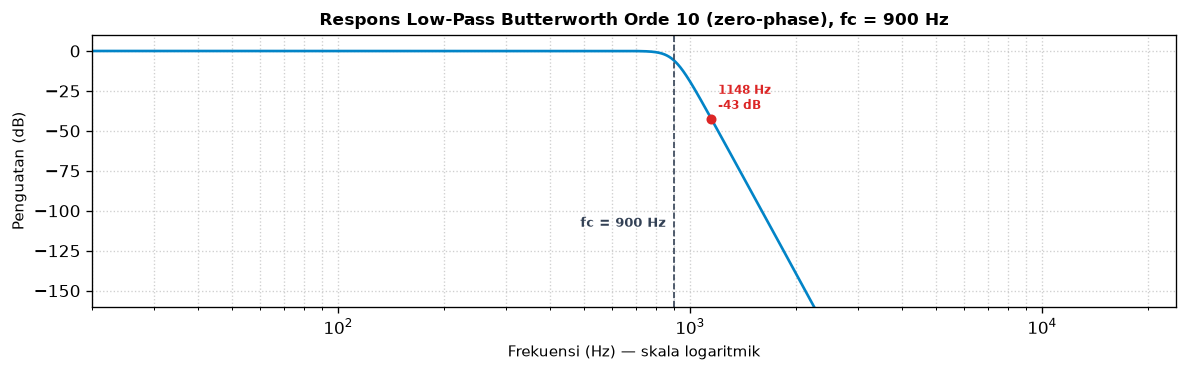

Redaman di fc (900 Hz) :   -6.0 dB
Redaman di  1148.4 Hz  :  -42.5 dB
Redaman di  2302.7 Hz  : -164.3 dB
Redaman di  3451.2 Hz  : -236.3 dB
Redaman di  4605.5 Hz  : -288.8 dB

Puncak sebelum :  -1.00 dBFS
Puncak sesudah :  -0.90 dBFS
ℹ️  Hasil filter sengaja TIDAK dinormalisasi ulang, agar perbandingan before/after adil.


In [9]:
from scipy.signal import butter, sosfiltfilt, sosfreqz

F_CUTOFF = 900.0
ORDE = 10

sos = butter(ORDE, F_CUTOFF, btype='lowpass', fs=sr, output='sos')

# Respons efektif sosfiltfilt = |H(f)|^2, yaitu dua kali redaman dalam dB
f_resp, h = sosfreqz(sos, worN=2 ** 15, fs=sr)
resp_db = 2 * 20 * np.log10(np.maximum(np.abs(h), 1e-12))

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.semilogx(f_resp[1:], resp_db[1:], color=C_SIGNAL, lw=1.6)
ax.axvline(F_CUTOFF, color=C_NEUTRAL, lw=1.0, linestyle='--')
ax.text(F_CUTOFF * 0.95, -110, f"fc = {F_CUTOFF:.0f} Hz", ha='right', fontsize=8,
        fontweight='bold', color=C_NEUTRAL)
for f_n in nada:
    g = np.interp(f_n, f_resp, resp_db)
    ax.plot(f_n, g, 'o', color=C_ALERT, ms=5)
    ax.annotate(f"{f_n:.0f} Hz\n{g:.0f} dB", xy=(f_n, g), xytext=(4, 6),
                textcoords='offset points', fontsize=7, color=C_ALERT, fontweight='bold')

ax.set_title(f"Respons Low-Pass Butterworth Orde {ORDE} (zero-phase), fc = {F_CUTOFF:.0f} Hz",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi (Hz) — skala logaritmik", fontsize=9)
ax.set_ylabel("Penguatan (dB)", fontsize=9)
ax.set_xlim(20, sr / 2)
ax.set_ylim(-160, 10)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

y_lpf = sosfiltfilt(sos, y)

print(f"Redaman di fc ({F_CUTOFF:.0f} Hz) : {np.interp(F_CUTOFF, f_resp, resp_db):6.1f} dB")
for f_n in nada:
    print(f"Redaman di {f_n:7.1f} Hz  : {np.interp(f_n, f_resp, resp_db):6.1f} dB")
print(f"\nPuncak sebelum : {20 * np.log10(np.max(np.abs(y))):6.2f} dBFS")
print(f"Puncak sesudah : {20 * np.log10(np.max(np.abs(y_lpf))):6.2f} dBFS")
print("ℹ️  Hasil filter sengaja TIDAK dinormalisasi ulang, agar perbandingan before/after adil.")

### 7.1 Before vs After — Waveform

Kedua panel memakai sumbu Y yang sama. Karena sebagian besar energi rekaman ini berada di bawah
$900\text{ Hz}$ (lihat porsi energi per zona di §4), bentuk gelombang **hampir tidak berubah** —
yang hilang terutama adalah "bulu-bulu" halus berfrekuensi tinggi di sepanjang sinyal.


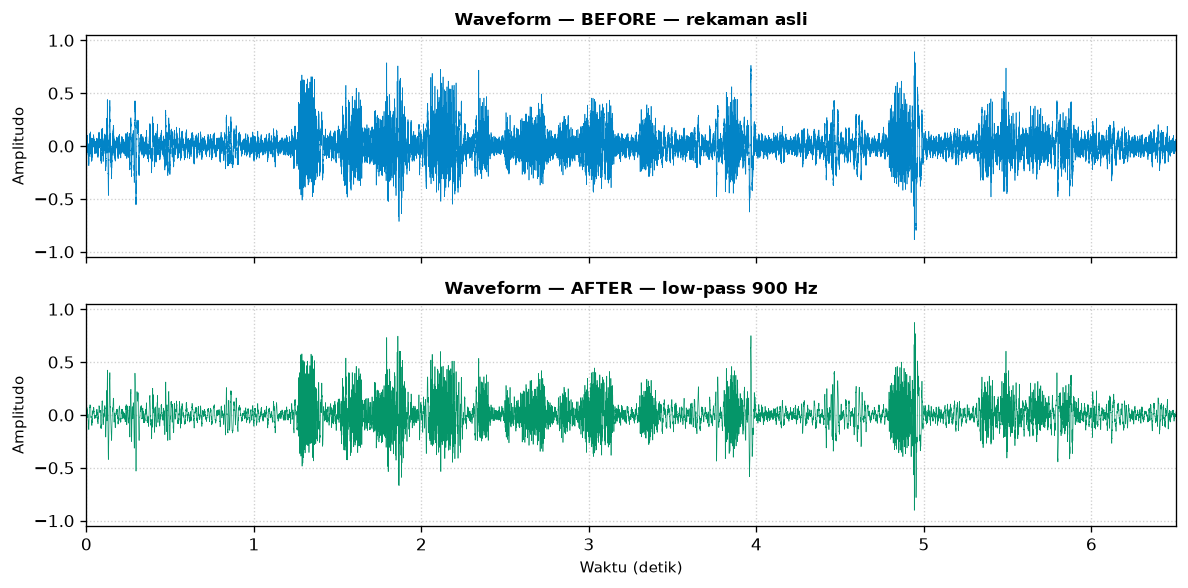

RMS sebelum : -18.12 dBFS
RMS sesudah : -18.32 dBFS  (-0.20 dB)
Energi yang dibuang filter : 4.5% dari total


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, sharey=True)

for ax, sig, judul, warna in (
    (axes[0], y,     'BEFORE — rekaman asli',                     C_SIGNAL),
    (axes[1], y_lpf, f'AFTER — low-pass {F_CUTOFF:.0f} Hz',         C_GOOD),
):
    ax.plot(t, sig, color=warna, lw=0.4)
    ax.set_title(f"Waveform — {judul}", fontsize=10, fontweight='bold')
    ax.set_ylabel("Amplitudo", fontsize=9)
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, linestyle=':', alpha=0.6)
axes[1].set_xlabel("Waktu (detik)", fontsize=9)
axes[1].set_xlim(0, t[-1])
plt.tight_layout()
plt.show()

rms_before = np.sqrt(np.mean(y ** 2))
rms_after = np.sqrt(np.mean(y_lpf ** 2))
print(f"RMS sebelum : {20 * np.log10(rms_before):6.2f} dBFS")
print(f"RMS sesudah : {20 * np.log10(rms_after):6.2f} dBFS  "
      f"({20 * np.log10(rms_after / rms_before):+.2f} dB)")
print(f"Energi yang dibuang filter : {100 * (1 - (rms_after / rms_before) ** 2):.1f}% dari total")

### 7.2 Before vs After — Spektrum FFT Logaritmik

Di sinilah efek filter paling jelas: di bawah $f_c$ kedua kurva berimpit, sedangkan di atas
$f_c$ kurva *after* jatuh curam dan duri-duri harmonik static noise lenyap.


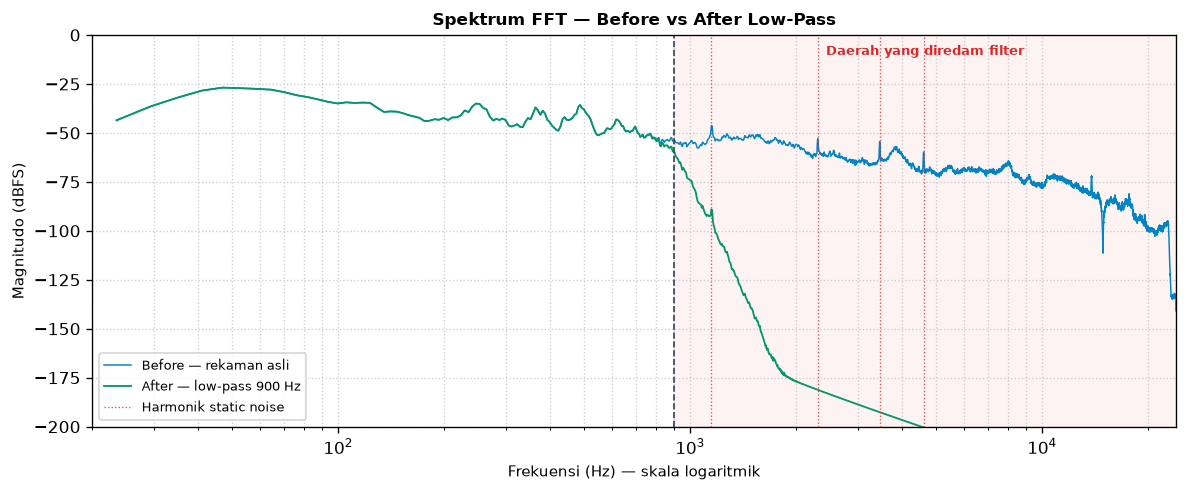

Level tiap harmonik static noise (spektrum rata-rata):
   1148.4 Hz :   -46.3 dBFS ->   -89.0 dBFS  (-42.7 dB)
   2302.7 Hz :   -53.0 dBFS ->  -181.2 dBFS  (-128.2 dB)
   3451.2 Hz :   -54.5 dBFS ->  -192.6 dBFS  (-138.1 dB)
   4605.5 Hz :   -60.0 dBFS ->  -200.4 dBFS  (-140.4 dB)


In [11]:
_, db_lpf = spectrum_dbfs(y_lpf, sr, n_fft=N_FFT_SPEC)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.axvspan(F_CUTOFF, sr / 2, color=C_ALERT, alpha=0.05)
ax.text(np.sqrt(F_CUTOFF * sr / 2), -5, "Daerah yang diredam filter", ha='center', va='top',
        fontsize=8, fontweight='bold', color=C_ALERT)

ax.semilogx(freqs[band], db[band], color=C_SIGNAL, lw=0.9, label='Before — rekaman asli')
ax.semilogx(freqs[band], db_lpf[band], color=C_GOOD, lw=1.1,
            label=f'After — low-pass {F_CUTOFF:.0f} Hz')
ax.axvline(F_CUTOFF, color=C_NEUTRAL, lw=1.0, linestyle='--')

for i, f_n in enumerate(nada):
    ax.axvline(f_n, color=C_ALERT, lw=0.8, linestyle=':', alpha=0.8,
               label='Harmonik static noise' if i == 0 else None)

ax.set_title("Spektrum FFT — Before vs After Low-Pass", fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi (Hz) — skala logaritmik", fontsize=9)
ax.set_ylabel("Magnitudo (dBFS)", fontsize=9)
ax.set_xlim(20, sr / 2)
ax.set_ylim(-200, 0)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

print("Level tiap harmonik static noise (spektrum rata-rata):")
for f_n in nada:
    i = int(np.argmin(np.abs(freqs - f_n)))
    print(f"  {f_n:7.1f} Hz : {db[i]:7.1f} dBFS -> {db_lpf[i]:7.1f} dBFS  "
          f"({db_lpf[i] - db[i]:+.1f} dB)")

### 7.3 Before vs After — Mel-Spektrogram

Kedua Mel-spektrogram dikonversi ke dB terhadap **acuan yang sama** (puncak daya rekaman asli).
Bila masing-masing memakai `ref=np.max` sendiri-sendiri, warna kedua gambar tidak lagi dapat
dibandingkan secara adil.


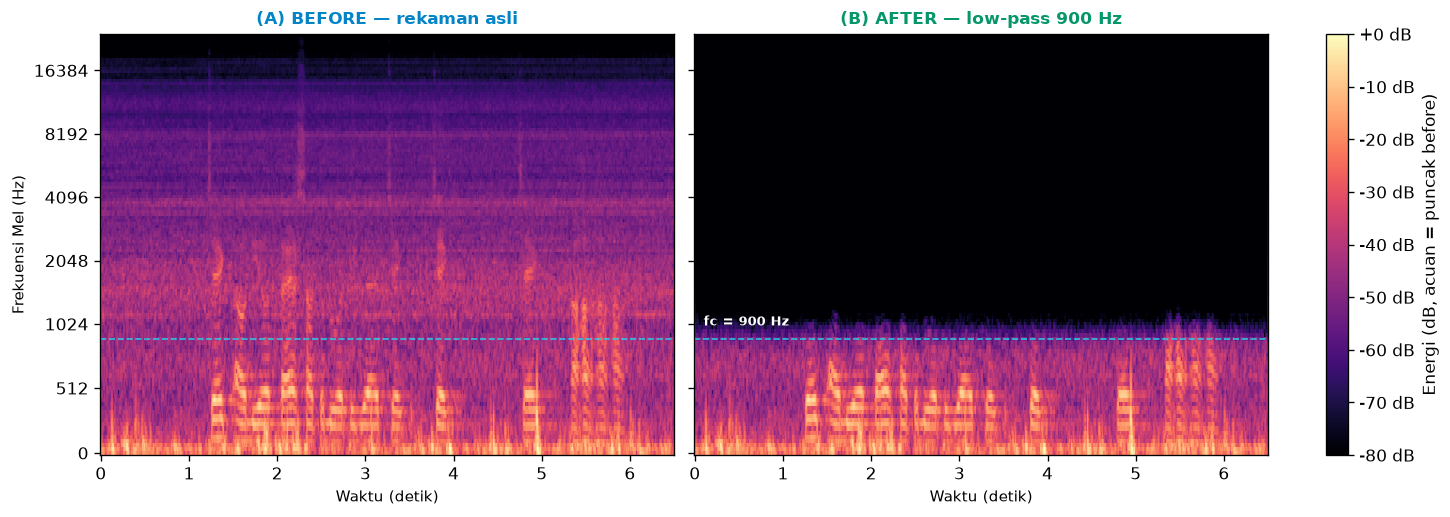

Energi rata-rata pada pita Mel terdekat tiap harmonik:
  pita ke- 35 (≈  1137 Hz) :  -38.7 dB ->  -78.6 dB
  pita ke- 56 (≈  2281 Hz) :  -45.6 dB ->  -80.0 dB
  pita ke- 68 (≈  3396 Hz) :  -48.8 dB ->  -80.0 dB
  pita ke- 77 (≈  4576 Hz) :  -52.8 dB ->  -80.0 dB


In [12]:
S_mel_lpf = librosa.feature.melspectrogram(y=y_lpf, sr=sr, n_fft=N_FFT, hop_length=HOP,
                                           n_mels=N_MELS, fmax=sr / 2)
REF = S_mel.max()
S_before_db = librosa.power_to_db(S_mel, ref=REF)
S_after_db = librosa.power_to_db(S_mel_lpf, ref=REF)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True, constrained_layout=True)
for ax, S_db, judul, warna in (
    (axes[0], S_before_db, '(A) BEFORE — rekaman asli',             C_SIGNAL),
    (axes[1], S_after_db,  f'(B) AFTER — low-pass {F_CUTOFF:.0f} Hz', C_GOOD),
):
    img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                                   x_axis='time', y_axis='mel', fmax=sr / 2,
                                   ax=ax, cmap='magma', vmin=-80, vmax=0)
    ax.axhline(F_CUTOFF, color='#22d3ee', lw=1.0, linestyle='--', alpha=0.9)
    ax.set_title(judul, fontsize=10, fontweight='bold', color=warna)
    ax.set_xlabel("Waktu (detik)", fontsize=9)
axes[0].set_ylabel("Frekuensi Mel (Hz)", fontsize=9)
axes[1].set_ylabel("")
axes[1].text(0.1, F_CUTOFF * 1.12, f"fc = {F_CUTOFF:.0f} Hz", color='white',
             fontsize=8, fontweight='bold')
fig.colorbar(img, ax=axes, format='%+2.0f dB', label='Energi (dB, acuan = puncak before)')
plt.show()

mel_f = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=sr / 2)
print("Energi rata-rata pada pita Mel terdekat tiap harmonik:")
for f_n in nada:
    i = int(np.argmin(np.abs(mel_f - f_n)))
    print(f"  pita ke-{i:3d} (≈{mel_f[i]:6.0f} Hz) : {S_before_db[i].mean():6.1f} dB -> "
          f"{S_after_db[i].mean():6.1f} dB")

### 7.4 Before vs After — Playback

Dengarkan keduanya bergantian. Perhatikan dua hal: (1) dengung melengking tinggi yang menetap
seharusnya hilang, dan (2) ucapan menjadi lebih "teredam" karena konsonan desis ikut terbuang.


In [13]:
# normalize=False pada KEDUA pemutar: bila tidak, pemutar akan menaikkan volume
# masing-masing sinyal ke puncaknya sendiri dan perbandingan kekerasan menjadi tidak adil.
print("🎵 BEFORE — rekaman asli:")
ipd.display(ipd.Audio(y, rate=sr, normalize=False))
print(f"🎵 AFTER — low-pass {F_CUTOFF:.0f} Hz:")
ipd.display(ipd.Audio(y_lpf, rate=sr, normalize=False))

🎵 BEFORE — rekaman asli:


🎵 AFTER — low-pass 900 Hz:
